# Prediction Error Reduction Attribution — Single Trunk Version

All editable inputs, comments, audit controls, execution switches and result loading are consolidated in the single code trunk below.

Models: {'HV': 'XGB', 'EC': 'XGB', 'Q3': 'XGB'}
Automatic input resolution: True


,Candidate Feature file
0,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...
1,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...
2,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...
3,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...
4,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...


Runtime configuration: /Users/zixuanzhao/Desktop/Corpus–Topic–Document/ML2/消融实验/Prediction_Error_Attribution/runtime_config_trunk.json


,Stage,Scientific role,Input file,Sheets (HV | EC | Q3),Targets (HV | EC | Q3)
0,S0,Composition-only,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV | EC | Q3-Eu,HV | EC | Q3-Eu
1,S1,Physicochemical feature engineering,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV | EC | Q3-Eu,HV | EC | Q3-Eu
2,S2,CTD-derived CPSP knowledge,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV | EC | Q3-Eu,HV | EC | Q3-Eu


Automatic input audit resolved a unique mapping:
  S0: /Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature1.xlsx | targets={'HV': 'Hardness/HV', 'EC': 'EC/%IACS', 'Q3': 'Q3-Euclidean'}
  S1: /Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature2.xlsx | targets={'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'}
  S2: /Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature3.xlsx | targets={'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'}
Resolved configuration: /Users/zixuanzhao/Desktop/Corpus–Topic–Document/ML2/消融实验/Prediction_Error_Attribution/auto_resolved_config.json
Input audit passed. Common IDs and feature counts:
Property Stage  Common_Valid_IDs  Feature_Count
      HV    S0              1136              7
      HV    S1              1136             17
      HV    S2              1136             24
      EC    S0              1136              7
      EC    S1              1136             14
      EC    S2              1136             22
      Q3    S0             

,Stage,Resolved file,Resolved targets
0,S0,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,Hardness/HV | EC/%IACS | Q3-Euclidean
1,S1,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV | EC | Q3-Eu
2,S2,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV | EC | Q3-Eu


,Property,Stage,Source_Target_Column,Common_Valid_IDs,Feature_Count
0,HV,S0,Hardness/HV,1136,7
1,HV,S1,HV,1136,17
2,HV,S2,HV,1136,24
3,EC,S0,EC/%IACS,1136,7
4,EC,S1,EC,1136,14
5,EC,S2,EC,1136,22
6,Q3,S0,Q3-Euclidean,1136,7
7,Q3,S1,Q3-Eu,1136,18
8,Q3,S2,Q3-Eu,1136,23


Shared test IDs: 228


,Property,Stage,Model,Optimized,Feature_Count,Train_R2,Test_R2,Test_RMSE,Test_Target_SD_ddof0,Test_NRMSE,CV_R2_training_only,CV_RMSE_training_only
0,HV,S0,XGB,False,7,0.519083,0.538739,52.919378,77.918649,0.679162,NaN,NaN
1,HV,S1,XGB,False,17,0.519821,0.540731,52.805002,77.918649,0.677694,NaN,NaN
2,HV,S2,XGB,False,24,0.909730,0.821174,32.950093,77.918649,0.422878,NaN,NaN
3,HV,S3,XGB,True,24,0.901010,0.825758,32.525007,77.918649,0.417423,0.806302,33.762750
4,EC,S0,XGB,False,7,0.406875,0.396658,9.407800,12.111732,0.776751,NaN,NaN
5,EC,S1,XGB,False,14,0.407078,0.394376,9.425578,12.111732,0.778219,NaN,NaN
6,EC,S2,XGB,False,22,0.843123,0.679765,6.853943,12.111732,0.565893,NaN,NaN
7,EC,S3,XGB,True,22,0.823239,0.685398,6.793399,12.111732,0.560894,0.634090,7.364030
8,Q3,S0,XGB,False,7,0.597683,0.554147,0.082041,0.122867,0.667722,NaN,NaN
9,Q3,S1,XGB,False,18,0.607083,0.575938,0.080011,0.122867,0.651200,NaN,NaN


,Property,E0,E1,E2,E3,Physics contribution,CTD contribution,Model contribution,Residual error,Physics_%_of_E0,CTD_%_of_E0,Model_%_of_E0,Residual_%_of_E0,Telescoping_Check,Negative_Component_Flag
0,HV,0.679162,0.677694,0.422878,0.417423,0.001468,0.254816,0.005456,0.417423,0.216131,37.519167,0.803271,61.461431,0.0,False
1,EC,0.776751,0.778219,0.565893,0.560894,-0.001468,0.212326,0.004999,0.560894,-0.188963,27.335127,0.643558,72.210278,0.0,True
2,Q3,0.667722,0.651200,0.491806,0.472097,0.016522,0.159394,0.019709,0.472097,2.474371,23.871346,2.951651,70.702632,0.0,False


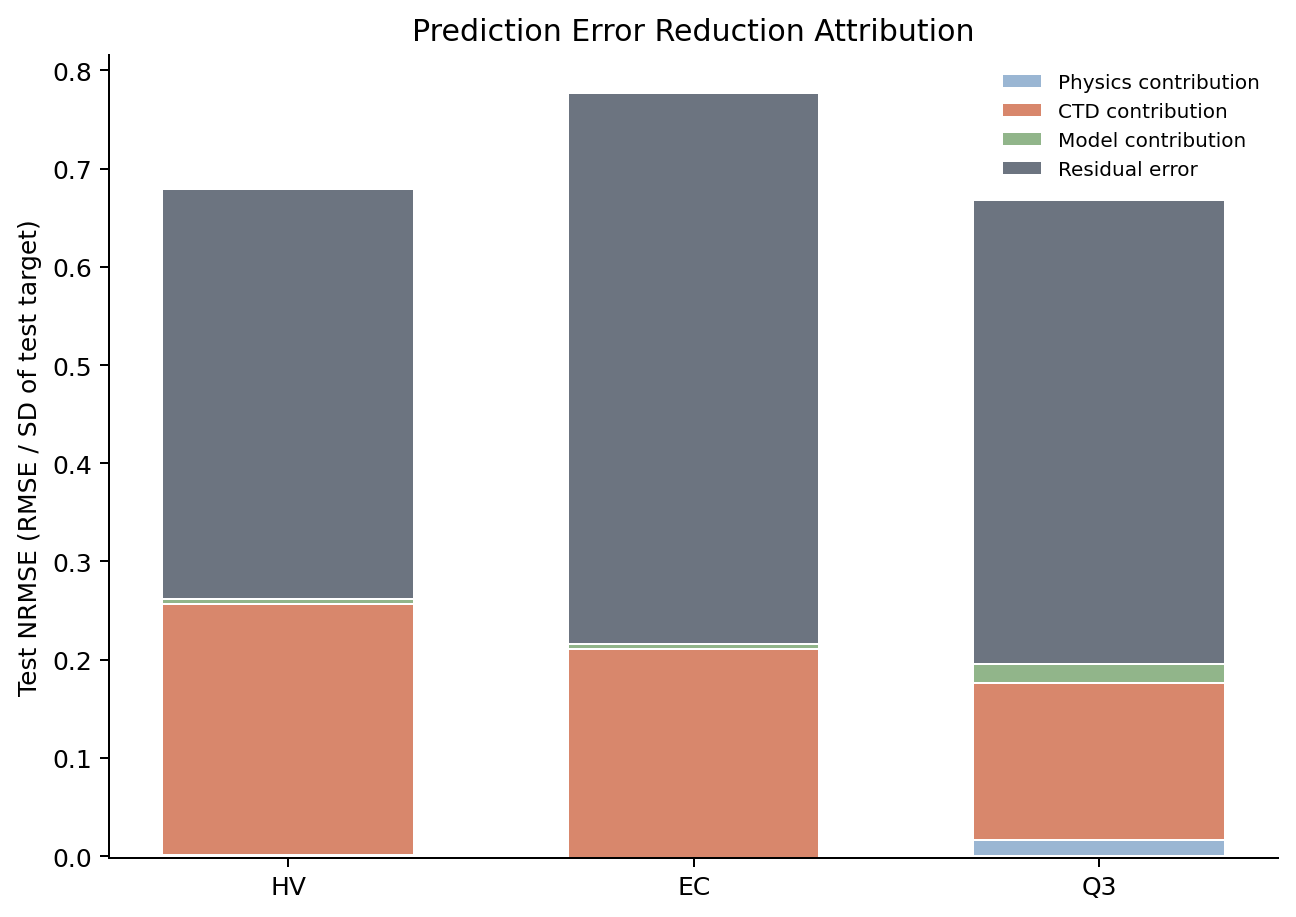

In [10]:
# ======================================================================================
# PREDICTION ERROR ATTRIBUTION — SINGLE USER CONFIGURATION AND EXECUTION TRUNK
# ======================================================================================
# Scientific definition of the four stages:
#   S0 = composition-only baseline, fixed XGBoost
#   S1 = S0 + conventional physicochemical descriptors, fixed XGBoost
#   S2 = S1 + CTD-derived CPSP descriptors, fixed XGBoost
#   S3 = exactly the S2 samples/features + training-only CV optimization of XGBoost
#
# File-name numbers do not define the scientific order. The dictionary keys S0/S1/S2
# below determine the order. Keep the formal-run switch False until the audit passes.
# Quick results are diagnostic only and must not be reported as formal paper results.
# ======================================================================================

from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
from IPython.display import display, Image

# [1] Core files -----------------------------------------------------------------------
WORK_DIR = Path('/Users/zixuanzhao/Desktop/Corpus–Topic–Document/ML2/消融实验/Prediction_Error_Attribution')
BASE_CONFIG_PATH = WORK_DIR / 'attribution_config.json'
RUNTIME_CONFIG_PATH = WORK_DIR / 'runtime_config_trunk.json'
SCRIPT_PATH = WORK_DIR / 'prediction_error_attribution.py'

# [2] Automatic input audit ------------------------------------------------------------
# Only maintain the candidate list. The program automatically assigns S0/S1/S2 by
# checking sheets, target aliases, required features, common IDs and target equality.
AUTO_RESOLVE_INPUTS = True
CANDIDATE_FEATURE_FILES = [
    '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature1.xlsx',
    '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature2.xlsx',
    '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature1.xlsx',
    '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature2.xlsx',
    '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature3.xlsx',
]

# Manual fallback used only when AUTO_RESOLVE_INPUTS=False.
STAGE_FILES = {
    'S0': '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature3.xlsx',
    'S1': '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature1.xlsx',
    'S2': '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature2.xlsx',
}

# [3] Sheet names ----------------------------------------------------------------------
STAGE_SHEETS = {
    'S0': {'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'},
    'S1': {'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'},
    'S2': {'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'},
}

# [4] Target-column names in each workbook -------------------------------------------
# The current S0 table uses long target names; S1/S2 use short target names.
STAGE_TARGET_COLUMNS = {
    'S0': {'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'},
    'S1': {'HV': 'HV',          'EC': 'EC',       'Q3': 'Q3-Eu'},
    'S2': {'HV': 'HV',          'EC': 'EC',       'Q3': 'Q3-Eu'},
}

# [5] Model, split and optimization settings ----------------------------------------
MODEL_BY_PROPERTY = {'HV': 'XGB', 'EC': 'XGB', 'Q3': 'XGB'}
RANDOM_SEED = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
STAGE3_OPTIMIZER = 'optuna'       # 'optuna' or 'randomized'
OPTUNA_TRIALS = 150               # Increase to 200–300 for a deeper formal search
OPTUNA_TARGET_CV_R2 = 0.90        # Training-CV target only; never a test-set target
STAGE3_SEARCH_ITERATIONS = 30     # Used only when optimizer='randomized'

# [6] Execution switches -------------------------------------------------------------
RUN_AUDIT = True                 # Always recommended after changing an input table
RUN_QUICK_TEST = False           # True = 3 parameter draws; diagnostic only
RUN_FORMAL_EXPERIMENT = False    # True = formal search defined above
USE_QUICK_RESULTS = True         # False = display formal results from results/

# ======================================================================================
# AUTOMATED SECTION — normally no manual edits are needed below this line
# ======================================================================================
assert WORK_DIR.exists(), f'Missing work directory: {WORK_DIR}'
assert BASE_CONFIG_PATH.exists(), f'Missing base config: {BASE_CONFIG_PATH}'
assert SCRIPT_PATH.exists(), f'Missing analysis script: {SCRIPT_PATH}'

with BASE_CONFIG_PATH.open('r', encoding='utf-8') as f:
    config = json.load(f)
config.setdefault('auto_input_audit', {})['enabled'] = AUTO_RESOLVE_INPUTS
config['auto_input_audit']['candidate_files'] = CANDIDATE_FEATURE_FILES
for stage in ['S0', 'S1', 'S2']:
    config['stages'][stage]['file'] = STAGE_FILES[stage]
    config['stages'][stage]['sheets'] = STAGE_SHEETS[stage]
    config['stages'][stage]['target_columns'] = STAGE_TARGET_COLUMNS[stage]
for prop in ['HV', 'EC', 'Q3']:
    config['targets'][prop]['model'] = MODEL_BY_PROPERTY[prop]
config['random_seed'] = RANDOM_SEED
config['test_size'] = TEST_SIZE
config['cv_folds'] = CV_FOLDS
config['stage3_optimizer'] = STAGE3_OPTIMIZER
config['optuna_trials'] = OPTUNA_TRIALS
config['optuna_target_cv_r2'] = OPTUNA_TARGET_CV_R2
config['stage3_search_iterations'] = STAGE3_SEARCH_ITERATIONS
with RUNTIME_CONFIG_PATH.open('w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
RUN_CONFIG_PATH = RUNTIME_CONFIG_PATH

configuration_table = pd.DataFrame([
    {
        'Stage': stage,
        'Scientific role': config['stages'][stage]['label'],
        'Input file': STAGE_FILES[stage],
        'Sheets (HV | EC | Q3)': ' | '.join(STAGE_SHEETS[stage][p] for p in ['HV', 'EC', 'Q3']),
        'Targets (HV | EC | Q3)': ' | '.join(STAGE_TARGET_COLUMNS[stage][p] for p in ['HV', 'EC', 'Q3']),
    } for stage in ['S0', 'S1', 'S2']
])
print('Models:', MODEL_BY_PROPERTY)
print('Automatic input resolution:', AUTO_RESOLVE_INPUTS)
if AUTO_RESOLVE_INPUTS:
    display(pd.DataFrame({'Candidate Feature file': CANDIDATE_FEATURE_FILES}))
print('Runtime configuration:', RUNTIME_CONFIG_PATH)
display(configuration_table)

if RUN_AUDIT:
    audit = subprocess.run(
        [sys.executable, str(SCRIPT_PATH), '--config', str(RUNTIME_CONFIG_PATH), '--audit-only'],
        cwd=WORK_DIR, text=True, capture_output=True
    )
    print(audit.stdout)
    if audit.returncode != 0:
        print(audit.stderr)
        raise RuntimeError('Input audit failed. Correct settings [2]–[4] before training.')
    resolved_path = WORK_DIR / 'auto_resolved_config.json'
    if AUTO_RESOLVE_INPUTS and resolved_path.exists():
        RUN_CONFIG_PATH = resolved_path
        with resolved_path.open('r', encoding='utf-8') as f:
            config = json.load(f)
        resolved_mapping = pd.DataFrame([
            {
                'Stage': stage,
                'Resolved file': config['stages'][stage]['file'],
                'Resolved targets': ' | '.join(config['stages'][stage]['target_columns'][p] for p in ['HV', 'EC', 'Q3']),
            } for stage in ['S0', 'S1', 'S2']
        ])
        print('Automatically resolved unique Stage mapping:')
        display(resolved_mapping)
    audit_table = pd.read_csv(Path(config['output_directory']) / 'input_audit.csv')
    split_table = pd.read_csv(Path(config['output_directory']) / 'split_map.csv')
    display(audit_table[['Property', 'Stage', 'Source_Target_Column', 'Common_Valid_IDs', 'Feature_Count']])
    test_sets = {
        p: set(split_table.query("Property == @p and Split == 'Test'")['ID'].astype(str))
        for p in ['HV', 'EC', 'Q3']
    }
    assert test_sets['HV'] == test_sets['EC'] == test_sets['Q3'], 'Test IDs differ across properties'
    print('Shared test IDs:', len(test_sets['HV']))

if RUN_QUICK_TEST:
    quick = subprocess.run(
        [sys.executable, str(SCRIPT_PATH), '--config', str(RUN_CONFIG_PATH), '--quick'],
        cwd=WORK_DIR, text=True
    )
    if quick.returncode != 0:
        raise RuntimeError('Quick experiment failed.')

if RUN_FORMAL_EXPERIMENT:
    formal = subprocess.run(
        [sys.executable, str(SCRIPT_PATH), '--config', str(RUN_CONFIG_PATH)],
        cwd=WORK_DIR, text=True
    )
    if formal.returncode != 0:
        raise RuntimeError('Formal experiment failed.')

RESULT_DIR = Path(config['output_directory'] + ('_quick' if USE_QUICK_RESULTS else ''))
required = ['run_summary.csv', 'attribution_summary.csv', 'best_parameters.csv', 'predictions_long.csv']
missing = [name for name in required if not (RESULT_DIR / name).exists()]
if missing:
    print(f'Result display skipped. Missing in {RESULT_DIR}: {missing}')
    print('Run the corresponding quick or formal experiment, then execute this trunk again.')
else:
    run_summary = pd.read_csv(RESULT_DIR / 'run_summary.csv')
    attribution = pd.read_csv(RESULT_DIR / 'attribution_summary.csv')
    assert set(run_summary['Model']) == {'XGB'}, run_summary['Model'].unique()
    assert attribution['Telescoping_Check'].abs().max() < 1e-10
    display(run_summary[[
        'Property', 'Stage', 'Model', 'Optimized', 'Feature_Count',
        'Train_R2', 'Test_R2', 'Test_RMSE', 'Test_Target_SD_ddof0', 'Test_NRMSE',
        'CV_R2_training_only', 'CV_RMSE_training_only'
    ]])
    display(attribution)
    figure_path = RESULT_DIR / 'prediction_error_attribution.png'
    if figure_path.exists():
        display(Image(filename=str(figure_path)))

#   E = Test NRMSE = Test RMSE / population SD(y_test).
#   dPhysics = E0-E1; dCTD = E1-E2; dModel = E2-E3; Residual = E3.
#   Do not use skew R2 as prediction error.
#   Do not truncate negative contributions to zero.
#   Residual error is not numerically equivalent to literature uncertainty.